# AI-Based Jira Ticket Priority Prediction System

## Exploratory Data Analysis (EDA)

**Course:** Software Engineering for Machine Learning

**Dataset:** GFG_FINAL.csv

In [1]:
import pandas as pd 
import numpy as np 
import re 
import string 
import matplotlib.pyplot as plt
import nltk

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords")

try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")

from nltk.corpus import stopwords 
from nltk.stem import WordNetLemmatizer 
nltk.download('wordnet')
nltk.download('omw-1.4')
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
df = pd.read_csv('../data/raw/GFG_FINAL.csv')
df.head(5)


,Summary,Issue key,Issue id,Issue Type,Status,Project key,Project name,Project type,Project lead,Project description,Project url,Priority,Resolution,Assignee,Reporter,Creator,Created,Updated,Last Viewed,Resolved,Affects Version/s,Affects Version/s.1,Affects Version/s.2,Affects Version/s.3,Affects Version/s.4,Affects Version/s.5,Affects Version/s.6,Affects Version/s.7,Fix Version/s,Component/s,Component/s.1,Component/s.2,Component/s.3,Due Date,Votes,Labels,Labels.1,Labels.2,Labels.3,Labels.4,Labels.5,Labels.6,Description,Environment,Original Estimate,Remaining Estimate,Time Spent,Work Ratio,Σ Original Estimate,Σ Remaining Estimate,Σ Time Spent,Security Level,Inward issue link (Blocker),Outward issue link (Blocker),Inward issue link (Cause),Outward issue link (Cause),Inward issue link (Cloners),Outward issue link (Cloners),Inward issue link (Detail),Inward issue link (Duplicate),Inward issue link (Duplicate).1,Inward issue link (Duplicate).2,Inward issue link (Duplicate).3,Inward issue link (Duplicate).4,Inward issue link (Duplicate).5,Inward issue link (Duplicate).6,Inward issue link (Duplicate).7,Inward issue link (Duplicate).8,Inward issue link (Duplicate).9,Inward issue link (Duplicate).10,Inward issue link (Duplicate).11,Inward issue link (Duplicate).12,Inward issue link (Duplicate).13,Inward issue link (Duplicate).14,Inward issue link (Duplicate).15,Inward issue link (Duplicate).16,Inward issue link (Duplicate).17,Inward issue link (Duplicate).18,Inward issue link (Duplicate).19,Inward issue link (Duplicate).20,Inward issue link (Duplicate).21,Inward issue link (Duplicate).22,Inward issue link (Duplicate).23,Inward issue link (Duplicate).24,Inward issue link (Duplicate).25,Inward issue link (Duplicate).26,Inward issue link (Duplicate).27,Inward issue link (Duplicate).28,Inward issue link (Duplicate).29,Inward issue link (Duplicate).30,Outward issue link (Duplicate),Outward issue link (Duplicate).1,Outward issue link (Duplicate).2,Outward issue link (Duplicate).3,Outward issue link (Duplicate).4,Outward issue link (Duplicate).5,Outward issue link (Duplicate).6,Inward issue link (Follows),Outward issue link (Follows),Outward issue link (Follows).1,Inward issue link (Part),Outward issue link (Part),Inward issue link (Reference),Inward issue link (Reference).1,Outward issue link (Reference),Outward issue link (Reference).1,Outward issue link (Reference).2,Outward issue link (Reference).3,Outward issue link (Reference).4,Outward issue link (Regression),Attachment,Attachment.1,Attachment.2,Attachment.3,Attachment.4,Attachment.5,Attachment.6,Attachment.7,Attachment.8,Attachment.9,Attachment.10,Attachment.11,Attachment.12,Attachment.13,Attachment.14,Attachment.15,Attachment.16,Attachment.17,Attachment.18,Attachment.19,Attachment.20,Attachment.21,Attachment.22,Attachment.23,Attachment.24,Custom field (Accept),Custom field (Actual Result),Custom field (Add-on Type),Custom field (Affects Clover-for-Eclipse),Custom field (Animal),Custom field (Atlassian Sweeps),Custom field (Attendees),Custom field (Backlog Order),Custom field (Backlog Order (Obsolete)),Custom field (Birthday),Custom field (Budget),Custom field (Bug Fix Policy),Custom field (Bug/Suggestion Type),Custom field (Bugmaster Rank),Custom field (Business Value),Custom field (Business Value).1,Custom field (CVE ID),Custom field (CVSS Score),Custom field (CVSS Severity),Custom field (CVSSv3 Vector),Custom field (Category),Custom field (Comments),Custom field (Company),Custom field (Company Name),Custom field (Complexity),Custom field (Confidence Level),Custom field (Confluence Page Id),Custom field (Contact Email),Custom field (Contact Name),Custom field (Credit),Custom field (Current Status),Custom field (Customer Email),Custom field (Date of First Response),Custom field (Demo Cascader),Custom field (Deployment Type),Custom field (Designer),Custom field (Dev Provided By),Custom field (Developed By),Custom field (Development Effort),Custom field (Do you intend to migrate to th

In [3]:
df.shape

(49000, 491)

In [4]:
# Select only required columns
jira_df = df[['Summary', 'Priority']].copy()

jira_df.head()

,Summary,Priority
0,Authentication failed when attempting Fetch command,High
1,OAuth token keeps expiring,Low
2,Mercurial: No column for revision/changeset number,NaN
3,Add an option to disable `git lfs ls-files` on startup,NaN
4,Unable to start SourceTree after updating from older version to 3.4.12,Medium


In [5]:
jira_df.isnull().sum()

Summary        0
Priority    7154
dtype: int64

In [6]:
# Remove rows where Priority is missing
jira_df = jira_df.dropna(subset=['Priority'])

# Reset index
jira_df = jira_df.reset_index(drop=True)

print("Dataset shape after removing missing values:")
print(jira_df.shape)

Dataset shape after removing missing values:
(41846, 2)


In [7]:
jira_df['Priority'].value_counts()

Priority
Low        37828
High        1813
Medium      1323
Highest      882
Name: count, dtype: int64

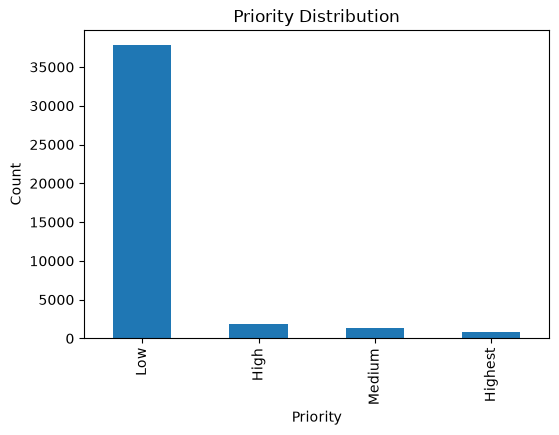

In [8]:
jira_df['Priority'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.show()

In [9]:
jira_df['Priority'].value_counts(normalize=True) * 100

Priority
Low        90.398126
High        4.332553
Medium      3.161593
Highest     2.107728
Name: proportion, dtype: float64

The target variable (Priority) is highly imbalanced. Approximately 90.4% of the records belong to the Low priority class, while the remaining classes constitute less than 10% of the dataset. Hence, evaluation metrics beyond accuracy will be used. SO we will use LogisticRegression(class_weight='balanced'), so that more importance is given to minority classes.

In [10]:
# Display first 10 ticket summaries
jira_df['Summary'].head(10)

0                        Authentication failed when attempting Fetch command
1                                                 OAuth token keeps expiring
2    Unable to start SourceTree after updating from older version to 3.4.12 
3                                              Keesp Asking for GitHub Login
4                 Dark Theme - history changed files not displayed correctly
5                                     Unable to know if the time is AM or PM
6              Fix for  Git Buffer Overflow - CVE-2022-41903, CVE-2022-23521
7                                       Failed to start after windows update
8                                          History view column sizes madness
9                         Upadate embedded Git binary and create new release
Name: Summary, dtype: str

In [11]:
# Display 10 random summaries
jira_df['Summary'].sample(10, random_state=42)



29821         Not able to check out remote branch with pipe (vertical line) character
24319               'Keep staged changes' checkbox doesn't work when stashing changes
33766                                                      commit time in 24h format 
24445    Authentication failure - Keeps attempting to authenticate on single request.
5014                         Code signing timestamp is missing from SourceTree v3.2.6
10210                                                    On push not select baranches
12286                                 Impossible to access to the Remote Account page
18701                                       Калькулятор скидки: не правильный расчет.
23072                                                       添加大量文件后，SourceTree会长时间无响应
28147                                        Custom Actions broken in Beta-3.3.0-3678
Name: Summary, dtype: str

In [12]:
# Length of each ticket summary
jira_df['Summary_Length'] = jira_df['Summary'].str.len()

jira_df['Summary_Length'].describe()

count    41846.000000
mean        50.174473
std         23.040587
min          2.000000
25%         33.000000
50%         48.000000
75%         65.000000
max        240.000000
Name: Summary_Length, dtype: float64

In [13]:
jira_df.head()

,Summary,Priority,Summary_Length
0,Authentication failed when attempting Fetch command,High,52
1,OAuth token keeps expiring,Low,26
2,Unable to start SourceTree after updating from older version to 3.4.12,Medium,71
3,Keesp Asking for GitHub Login,Medium,29
4,Dark Theme - history changed files not displayed correctly,Low,58


This observation is important. Summary is neither too large nor too short. Also since mean is 50 and median is 48, so data is not highly skewed.
TF-iDF is good choice for this. If summaries had 5000-10000 characters, bERT or transformer would be needed.

✅ TF-IDF + Logistic Regression

The average ticket summary length is approximately 50 characters, with most summaries ranging between 33 and 65 characters. The relatively short and consistent length makes TF-IDF vectorization a suitable representation technique.

In [14]:
jira_df['Priority'].unique()

<ArrowStringArray>
['High', 'Low', 'Medium', 'Highest']
Length: 4, dtype: str

In [15]:
jira_df['Priority'].nunique()

4

The dataset was cleaned by removing records with missing values in the target attribute (Priority). The resulting dataset contains 41,846 labeled Jira tickets. The project uses the Summary field as the textual input and Priority as the target variable. Four priority classes are present: Low, Medium, High, and Highest. The dataset is highly imbalanced, with approximately 90% of the tickets belonging to the Low priority class.

In [16]:
# Save cleaned dataset
jira_df.to_csv("../data/processed/jira_cleaned.csv", index=False)

In [17]:
jira_df = pd.read_csv('../data/processed/jira_cleaned.csv')

In [18]:
jira_df.head()

,Summary,Priority,Summary_Length
0,Authentication failed when attempting Fetch command,High,52
1,OAuth token keeps expiring,Low,26
2,Unable to start SourceTree after updating from older version to 3.4.12,Medium,71
3,Keesp Asking for GitHub Login,Medium,29
4,Dark Theme - history changed files not displayed correctly,Low,58


In [19]:
jira_df['Summary'].sample(10, random_state=42)

29821         Not able to check out remote branch with pipe (vertical line) character
24319               'Keep staged changes' checkbox doesn't work when stashing changes
33766                                                      commit time in 24h format 
24445    Authentication failure - Keeps attempting to authenticate on single request.
5014                         Code signing timestamp is missing from SourceTree v3.2.6
10210                                                    On push not select baranches
12286                                 Impossible to access to the Remote Account page
18701                                       Калькулятор скидки: не правильный расчет.
23072                                                       添加大量文件后，SourceTree会长时间无响应
28147                                        Custom Actions broken in Beta-3.3.0-3678
Name: Summary, dtype: str

In [20]:
stop_words = stopwords.words('english')
print(len(stop_words))
print(stop_words[:30])

198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't"]


In [21]:
sample = jira_df.loc[0, "Summary"]

print(sample)

 Authentication failed when attempting Fetch command


In [22]:
print(string.punctuation)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [23]:

lemmatizer = WordNetLemmatizer() 
def clean_text(text):
    """
    Cleans a Jira ticket summary for NLP processing.

    Steps:
    1. Lowercase
    2. Remove punctuation
    3. Tokenize
    4. Remove stopwords
    5. Lemmatize
    6. Join tokens back into a sentence
    """    
   #  print('Original Text: ')
   #  print(text)
    #lowerCase
    text = text.lower()
    # print('Lower Case Text: ')
    # print(text)
    
    #Remove punctuation
    text = text.translate(
        str.maketrans('','',string.punctuation)
    )
    # print('Punctuation Removed Text: ')
    # print(text)

    #tokenize
    tokens = text.split()
    # print('Tokens: ')
    # print(tokens)

    #remove stopwords
    stop_words = set(stopwords.words("english"))
    important_words = {'not','no','nor'}
    custom_stop_words = [word for word in stop_words if word not in important_words]
    tokens = [token for token in tokens if token not in custom_stop_words]
    # print('Stopwords Removed: ')
    # print(tokens)

    #Lemmatize 
    tokens = [lemmatizer.lemmatize(token,pos='v')
             for token in tokens]
    # print('Lemmatized Tokens: ')
    # print(tokens)

    text = " ".join(tokens)
    return text
cleaned = clean_text(sample)
# print('Preprocessed Text: ')
# print(cleaned)

The cleaned tokens were concatenated into a sentence using Python's join() function, as TF-IDF vectorization requires textual documents rather than token lists.

In [24]:
jira_df['Clean_Summary'] = jira_df['Summary'].apply(clean_text)

In [25]:
jira_df.head()

,Summary,Priority,Summary_Length,Clean_Summary
0,Authentication failed when attempting Fetch command,High,52,authentication fail attempt fetch command
1,OAuth token keeps expiring,Low,26,oauth token keep expire
2,Unable to start SourceTree after updating from older version to 3.4.12,Medium,71,unable start sourcetree update older version 3412
3,Keesp Asking for GitHub Login,Medium,29,keesp ask github login
4,Dark Theme - history changed files not displayed correctly,Low,58,dark theme history change file not display correctly


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

tfidf = TfidfVectorizer()
tfidf.fit(jira_df["Clean_Summary"])
print("Vocabulary Size:", len(tfidf.vocabulary_))
X = tfidf.transform(jira_df['Clean_Summary'])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(jira_df['Priority'])
jira_df['Encoded_Priority'] = label_encoder.fit_transform(jira_df['Priority'])

Vocabulary Size: 1172


In [27]:
print(tfidf.vocabulary_["authentication"])
print(tfidf.vocabulary_["oauth"])
print(tfidf.vocabulary_["fetch"])

102
653
380


In [28]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[102])

authentication


In [29]:
X.shape

(41846, 1172)

In [30]:
jira_df.to_csv("../data/processed/jira_processed.csv", index=False)

In [31]:
jira_df = pd.read_csv("../data/processed/jira_processed.csv",keep_default_na=False)

In [32]:
jira_df.head()

,Summary,Priority,Summary_Length,Clean_Summary,Encoded_Priority
0,Authentication failed when attempting Fetch command,High,52,authentication fail attempt fetch command,0
1,OAuth token keeps expiring,Low,26,oauth token keep expire,2
2,Unable to start SourceTree after updating from older version to 3.4.12,Medium,71,unable start sourcetree update older version 3412,3
3,Keesp Asking for GitHub Login,Medium,29,keesp ask github login,3
4,Dark Theme - history changed files not displayed correctly,Low,58,dark theme history change file not display correctly,2


In [33]:
print(dict(zip(label_encoder.classes_,
               label_encoder.transform(label_encoder.classes_))))

{'High': np.int64(0), 'Highest': np.int64(1), 'Low': np.int64(2), 'Medium': np.int64(3)}


In [34]:
X = jira_df['Clean_Summary']
y = jira_df['Encoded_Priority']

In [35]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,random_state=42,stratify=y
)

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

In [37]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    random_state=42,max_iter=1000
)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [38]:
print(y_pred[:10])

[2 2 2 2 2 2 2 2 2 2]


In [39]:
label_encoder.inverse_transform(y_pred[:10])

array(['Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low',
       'Low'], dtype=object)

In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.9947431302270012


In [41]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       1.00      0.92      0.96       363
     Highest       1.00      0.92      0.96       176
         Low       0.99      1.00      1.00      7566
      Medium       1.00      1.00      1.00       265

    accuracy                           0.99      8370
   macro avg       1.00      0.96      0.98      8370
weighted avg       0.99      0.99      0.99      8370



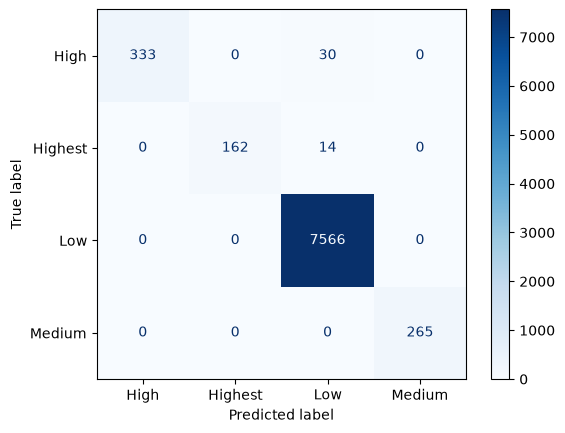

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.show()

In [43]:
import joblib

joblib.dump(model, "../artifacts/logistic_regression_model.pkl")
joblib.dump(tfidf, "../artifacts/tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "../artifacts/label_encoder.pkl")

['../artifacts/label_encoder.pkl']

In [44]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    jira_df["Clean_Summary"],
    jira_df["Priority"],   # <-- original priority column
    test_size=0.2,
    random_state=42,
    stratify=jira_df["Priority"]
)

In [45]:
train_df = pd.DataFrame({
    "Summary": X_train_text,
    "Priority": y_train_text
})

train_df[train_df["Priority"] == "Highest"].head(10)

,Summary,Priority
12838,update sourcetree windows 3410 3411 fail,Highest
18831,source tree application crash open,Highest
11117,sourcetree crash soon start,Highest
30772,update sourcetree windows 3410 3411 fail,Highest
30759,sourcetree crash soon start,Highest
33364,update 349 3410 fail,Highest
18890,cannot push upgrade,Highest
16256,cant start sourcetree update 3410,Highest
17992,update 349 3410 fail,Highest
11101,sourcetree shouldnt floor cpu especially not not use,Highest


In [46]:
train_df[train_df["Priority"] == "High"].head(10)

,Summary,Priority
7697,break link,High
18033,remote repository search not work project key not part project name,High
18296,run git lfs pull trigger every startup,High
35065,software update 3410 fail,High
12011,update impossible,High
4281,break link,High
17943,upadate embed git binary create new release,High
12907,sourcetree not update remote repository,High
2638,sourcetree push remote repo use embed git stick add servers rsa2 fingerprint,High
918,sourcetreeappcom web site point wrong version,High


In [47]:
import os
import sys

sys.path.append(os.path.abspath(".."))

In [48]:
from src.preprocessing import clean_text
from src.predictor import predict_priority

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
2026-06-30 17:02:08,462 | INFO | Loading model...
2026-06-30 17:02:08,469 | INFO | Model loaded successfully.


In [49]:
sample = "Authentication failed when attempting Fetch command"

prediction = predict_priority(sample)
print(prediction)

2026-06-30 17:02:08,477 | INFO | Prediction started for...
2026-06-30 17:02:08,477 | INFO | Authentication failed when attempting Fetch command
2026-06-30 17:02:08,488 | INFO | Predicted Priority: High


('High', np.float64(0.9045353151589388), {'High': np.float64(0.9045353151589388), 'Highest': np.float64(0.007952363116886588), 'Low': np.float64(0.08566353104714015), 'Medium': np.float64(0.00184879067703446)})


In [50]:
tickets = [
    "Application crashes immediately after deployment",
    "Unable to login due to OAuth token expiration",
    "Change dashboard theme color",
    "Add export to Excel feature",
    "Payment service timeout causing customer failure",
    "Authentication failed when attempting Fetch command", 
    "OAuth token keeps expiring", 
    "Dark Theme - history changed files not displayed correctly"
]

In [51]:
for ticket in tickets:

    prediction = predict_priority(ticket)

    print(f"Ticket : {ticket}")
    print(f"Priority : {prediction}")
    """
    prob_df = pd.DataFrame(
        probability,
        columns=label_encoder.classes_
    )
    print(prob_df)
    """
    

    print("-"*70)

2026-06-30 17:02:08,510 | INFO | Prediction started for...
2026-06-30 17:02:08,510 | INFO | Application crashes immediately after deployment
2026-06-30 17:02:08,526 | INFO | Predicted Priority: Low
2026-06-30 17:02:08,526 | INFO | Prediction started for...
2026-06-30 17:02:08,526 | INFO | Unable to login due to OAuth token expiration
2026-06-30 17:02:08,535 | INFO | Predicted Priority: Low
2026-06-30 17:02:08,535 | INFO | Prediction started for...
2026-06-30 17:02:08,535 | INFO | Change dashboard theme color
2026-06-30 17:02:08,543 | INFO | Predicted Priority: Low
2026-06-30 17:02:08,543 | INFO | Prediction started for...
2026-06-30 17:02:08,552 | INFO | Add export to Excel feature
2026-06-30 17:02:08,560 | INFO | Predicted Priority: Low
2026-06-30 17:02:08,560 | INFO | Prediction started for...
2026-06-30 17:02:08,560 | INFO | Payment service timeout causing customer failure
2026-06-30 17:02:08,568 | INFO | Predicted Priority: Low
2026-06-30 17:02:08,568 | INFO | Prediction started fo

Ticket : Application crashes immediately after deployment
Priority : ('Low', np.float64(0.9872551015176546), {'High': np.float64(0.0008900448422257107), 'Highest': np.float64(0.010486713209957121), 'Low': np.float64(0.9872551015176546), 'Medium': np.float64(0.001368140430162585)})
----------------------------------------------------------------------
Ticket : Unable to login due to OAuth token expiration
Priority : ('Low', np.float64(0.9911896945112684), {'High': np.float64(0.0024154723602047507), 'Highest': np.float64(0.000390786827728779), 'Low': np.float64(0.9911896945112684), 'Medium': np.float64(0.006004046300797901)})
----------------------------------------------------------------------
Ticket : Change dashboard theme color
Priority : ('Low', np.float64(0.989490964223847), {'High': np.float64(0.0037662135278371217), 'Highest': np.float64(0.0005302724369521), 'Low': np.float64(0.989490964223847), 'Medium': np.float64(0.006212549811363806)})
---------------------------------------

In [52]:
"""
import pandas as pd

prob_df = pd.DataFrame(
    probabilities,
    columns=label_encoder.classes_
)

print(prob_df)
""" 

'\nimport pandas as pd\n\nprob_df = pd.DataFrame(\n    probabilities,\n    columns=label_encoder.classes_\n)\n\nprint(prob_df)\n'

In [53]:
jira_df["Priority"].value_counts(normalize=True)

Priority
Low        0.903981
High       0.043326
Medium     0.031616
Highest    0.021077
Name: proportion, dtype: float64